In [20]:
import sys
!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [21]:
import subprocess
subprocess.run(['pip', 'install', 'wordcloud'], check=True)

CompletedProcess(args=['pip', 'install', 'wordcloud'], returncode=0)

# Load & merge both files

In [2]:
import pandas as pd

# Load both files
fake = pd.read_csv(r"C:\Users\DELL\Downloads\Fake.csv")
true = pd.read_csv(r"C:\Users\DELL\Downloads\True.csv")

# Add labels: 0 = Fake, 1 = Real
fake['label'] = 0
true['label'] = 1

# Merge into one dataset
df = pd.concat([fake, true], ignore_index=True)

print("Fake articles:", len(fake))
print("Real articles:", len(true))
print("Total articles:", len(df))
print("\nColumns:", df.columns.tolist())
df.head()

Fake articles: 23481
Real articles: 21417
Total articles: 44898

Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


# EDA — understand the data before modeling

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Fake: 23481 (52.3%)
Real: 21417 (47.7%)


C:\Users\DELL\AppData\Local\Temp\ipykernel_14364\3217193689.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#E8593C','#1D9E75'])


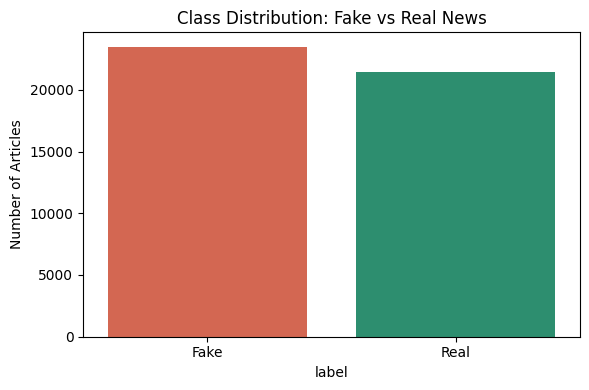

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class balance
print("Label distribution:")
print(df['label'].value_counts())
print(f"\nFake: {df[df['label']==0].shape[0]} ({df[df['label']==0].shape[0]/len(df)*100:.1f}%)")
print(f"Real: {df[df['label']==1].shape[0]} ({df[df['label']==1].shape[0]/len(df)*100:.1f}%)")

# Plot class balance
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['#E8593C','#1D9E75'])
plt.xticks([0,1], ['Fake', 'Real'])
plt.title("Class Distribution: Fake vs Real News")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

Average word count:
label
Fake    423.197905
Real    385.640099
Name: text_length, dtype: float64


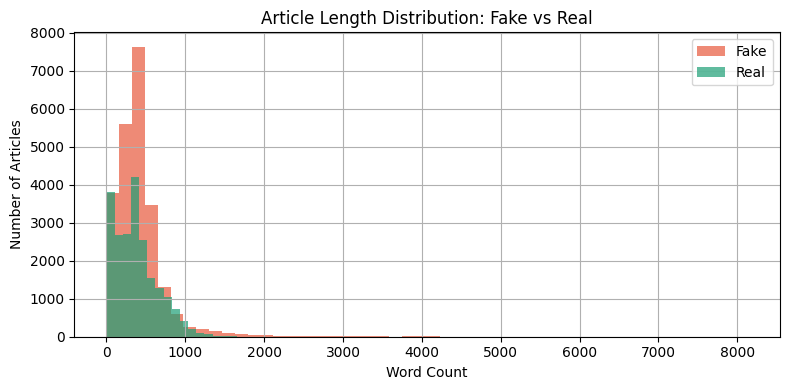

In [5]:
# Article length analysis
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

print("Average word count:")
print(df.groupby('label')['text_length'].mean().rename({0:'Fake', 1:'Real'}))

plt.figure(figsize=(8,4))
df[df['label']==0]['text_length'].hist(bins=50, alpha=0.7, color='#E8593C', label='Fake')
df[df['label']==1]['text_length'].hist(bins=50, alpha=0.7, color='#1D9E75', label='Real')
plt.xlabel("Word Count")
plt.ylabel("Number of Articles")
plt.title("Article Length Distribution: Fake vs Real")
plt.legend()
plt.tight_layout()
plt.savefig("length_distribution.png")
plt.show()

In [6]:
# Subject breakdown
print("Subjects in Fake news:")
print(df[df['label']==0]['subject'].value_counts())
print("\nSubjects in Real news:")
print(df[df['label']==1]['subject'].value_counts())

Subjects in Fake news:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

Subjects in Real news:
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


#  Text preprocessing & cleaning

In [8]:
import re
import string

# Combine title + text into one column (more information = better model)
df['content'] = df['title'] + ' ' + df['text']

# Text cleaning function
def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'\[.*?\]', '', text)               # remove text in brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\n', ' ', text)                   # remove newlines
    text = re.sub(r'\w*\d\w*', '', text)              # remove words containing numbers
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    return text

# Apply cleaning
df['content_clean'] = df['content'].apply(clean_text)

print("Original text sample:")
print(df['content'].iloc[0][:200])
print("\nCleaned text sample:")
print(df['content_clean'].iloc[0][:200])
print("\nCleaning done! Total articles:", len(df))

Original text sample:
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out

Cleaned text sample:
donald trump sends out embarrassing new year’s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to 

Cleaning done! Total articles: 44898


# TF-IDF Feature Extraction

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split first (IMPORTANT: split before TF-IDF to avoid data leakage)
X = df['content_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training articles:", X_train.shape[0])
print("Testing articles:", X_test.shape[0])

# TF-IDF Vectorizer
# max_features=50000: use top 50,000 most important words
# ngram_range=(1,2): use single words AND two-word phrases (e.g. "fake news", "donald trump")
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), stop_words='english')

# Fit on training data only, then transform both
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

Training articles: 35918
Testing articles: 8980

TF-IDF matrix shape (train): (35918, 50000)
TF-IDF matrix shape (test): (8980, 50000)


#  Train the Logistic Regression classifier

In [12]:
from sklearn.linear_model import LogisticRegression

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")
print("Training articles:", X_train_tfidf.shape[0])
print("Features (TF-IDF words/phrases):", X_train_tfidf.shape[1])

Model trained successfully!
Training articles: 35918
Features (TF-IDF words/phrases): 50000


# Evaluate the model


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 45)
print("        MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("=" * 45)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

        MODEL EVALUATION RESULTS
Accuracy  : 98.85%
Precision : 0.9868
Recall    : 0.9889
F1 Score  : 0.9879

Confusion Matrix:
[[4677   56]
 [  47 4200]]

Full Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4733
        Real       0.99      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



# Word Cloud — most common words in fake vs real news

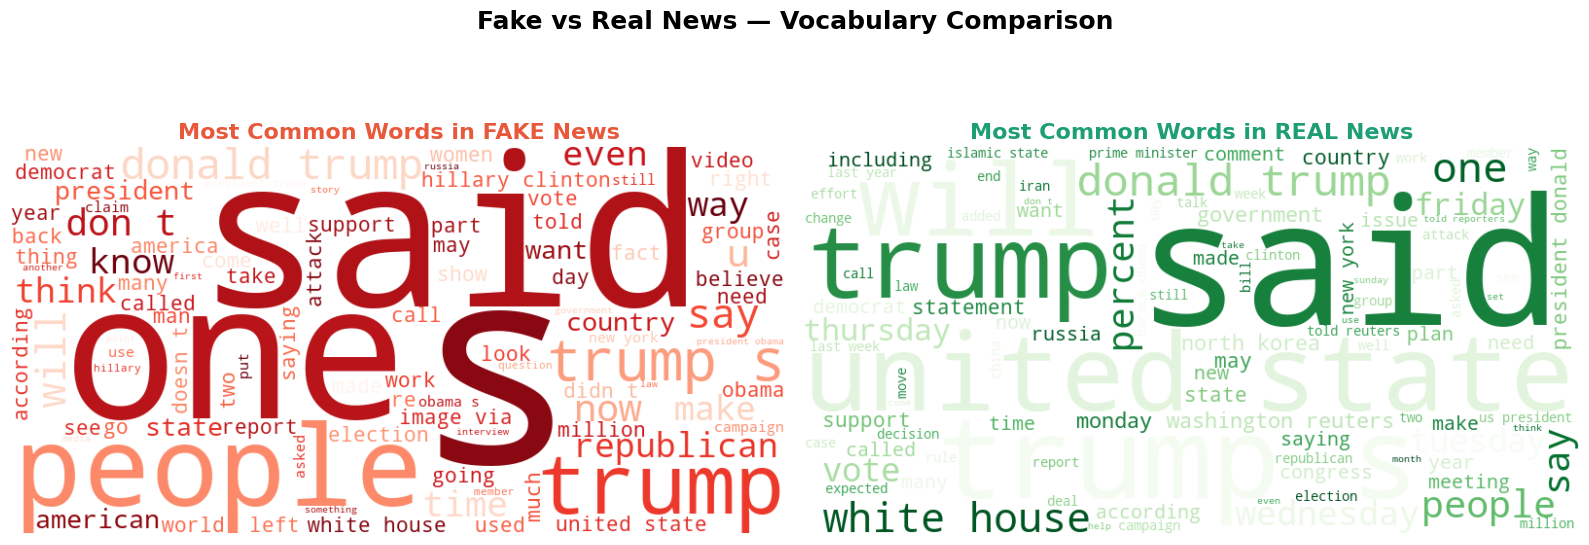

Word cloud saved!


In [22]:
from wordcloud import WordCloud

# Fake news word cloud
fake_text = ' '.join(df[df['label']==0]['content_clean'].tolist())
real_text = ' '.join(df[df['label']==1]['content_clean'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fake news
wc_fake = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words in FAKE News', fontsize=16, fontweight='bold', color='#E8593C')

# Real news
wc_real = WordCloud(width=800, height=400, background_color='white',
                    colormap='Greens', max_words=100).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common Words in REAL News', fontsize=16, fontweight='bold', color='#1D9E75')

plt.suptitle('Fake vs Real News — Vocabulary Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("wordcloud_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("Word cloud saved!")

In [ ]:
# Live News Predictor

In [23]:
def predict_news(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]

    label = "✅ REAL NEWS" if prediction == 1 else "🚨 FAKE NEWS"
    confidence = probability[prediction] * 100

    print("=" * 50)
    print(f"  PREDICTION  : {label}")
    print(f"  CONFIDENCE  : {confidence:.2f}%")
    print(f"  Fake prob   : {probability[0]*100:.2f}%")
    print(f"  Real prob   : {probability[1]*100:.2f}%")
    print("=" * 50)

In [24]:
# Test 1 — fake sounding article
predict_news("""
Trump secretly signs executive order banning all 
Muslims from entering the United States permanently, 
sources say the document was hidden from the public.
""")

  PREDICTION  : 🚨 FAKE NEWS
  CONFIDENCE  : 73.30%
  Fake prob   : 73.30%
  Real prob   : 26.70%


In [25]:
# Test 2 — real sounding article
predict_news("""
The Federal Reserve raised interest rates by 25 basis points 
on Wednesday, citing continued strength in the labor market 
and inflation moving toward its 2% target, Fed Chair stated.
""")

  PREDICTION  : ✅ REAL NEWS
  CONFIDENCE  : 55.07%
  Fake prob   : 44.93%
  Real prob   : 55.07%
